In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.linear_model import Perceptron
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

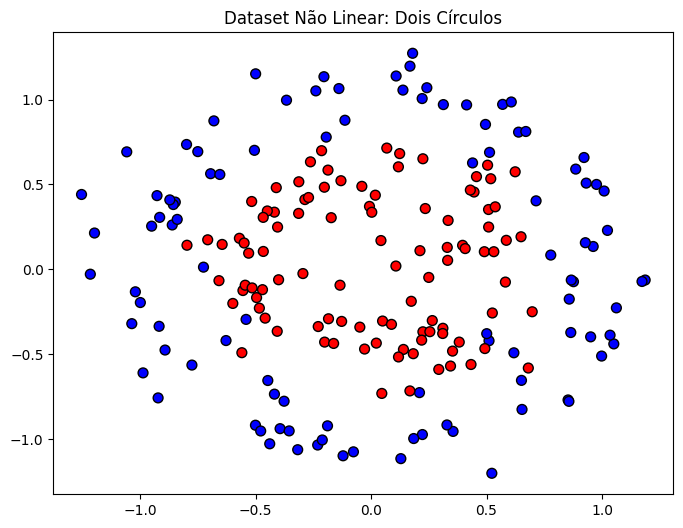

In [17]:
from sklearn.datasets import make_circles

# 1. Gerando os dados em formato de círculos
# factor: distância entre os círculos (0 a 1)
# noise: o "barulho" dos dados
X, y = make_circles(n_samples=200, factor=0.5, noise=0.15, random_state=42)

# 2. Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Visualização
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k', s=50)
plt.title("Dataset Não Linear: Dois Círculos")
plt.show()

Acurácia: 43.33%


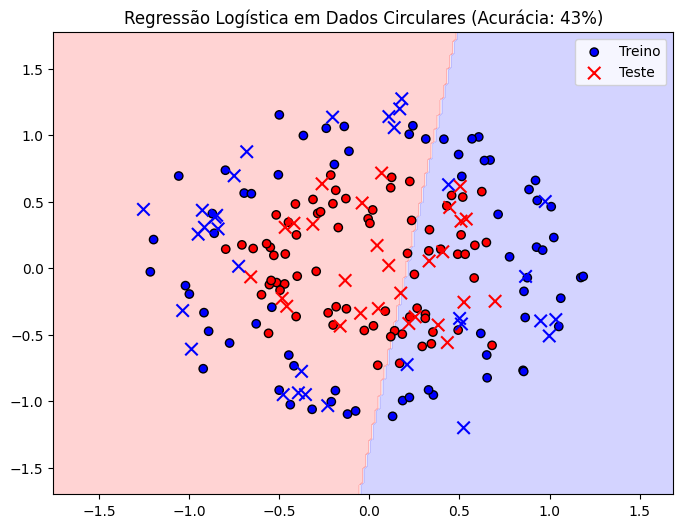

In [18]:
from sklearn.linear_model import LogisticRegression

# 1. Criar e treinar o modelo
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# 2. Avaliar
y_pred = log_reg.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Acurácia: {acc * 100:.2f}%") # Resultado será próximo de 50% (aleatório)

# 3. Visualizar a fronteira
plt.figure(figsize=(8, 6))

# Criar malha para o fundo
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = log_reg.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.2, cmap='bwr')
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='bwr', edgecolor='k', label='Treino')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='bwr', marker='x', s=80, label='Teste')

plt.title(f"Regressão Logística em Dados Circulares (Acurácia: {acc*100:.0f}%)")
plt.legend()
plt.show()

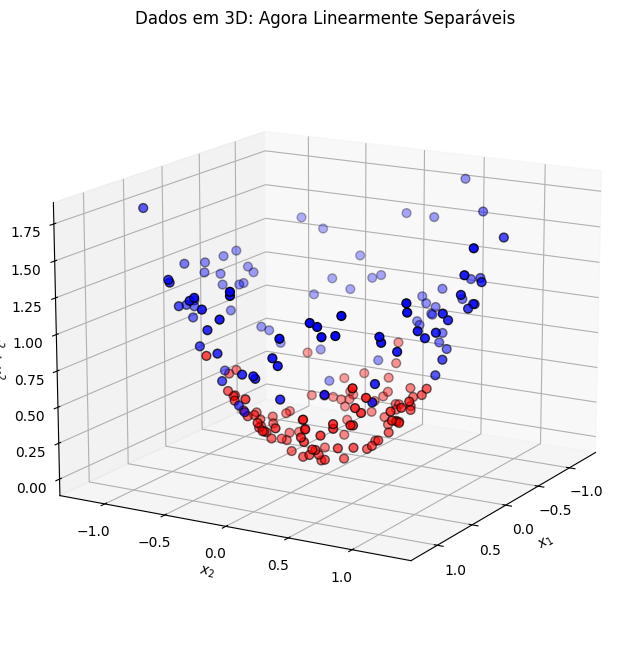

In [19]:
from mpl_toolkits.mplot3d import Axes3D

# 1. Calcula a terceira dimensão (soma dos quadrados)
z = X[:, 0]**2 + X[:, 1]**2

# 2. Configura o plot 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 3. Scatter plot 3D
ax.scatter(X[:, 0], X[:, 1], z, c=y, cmap='bwr', edgecolor='k', s=40)

# Labels
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$x_1^2 + x_2^2$')
ax.set_title('Dados em 3D: Agora Linearmente Separáveis')
# elev: ângulo sobre o plano x-y (elevação)
# azim: rotação em torno do eixo z (azimute)
ax.view_init(elev=15, azim=30)

plt.show()

In [20]:
# 1. Cria a 3ª dimensão e prepara os dados
z = (X[:, 0]**2 + X[:, 1]**2).reshape(-1, 1)
X_3d = np.hstack((X, z))

# 2. Divisão e Treino
X_train, X_test, y_train, y_test = train_test_split(X_3d, y, test_size=0.3, random_state=42)
clf = Perceptron()
clf.fit(X_train, y_train)

# 3. Resultado
acc = accuracy_score(y_test, clf.predict(X_test))
print(f"Acurácia em 3D: {acc*100:.2f}%") # Agora será 100%

Acurácia em 3D: 93.33%


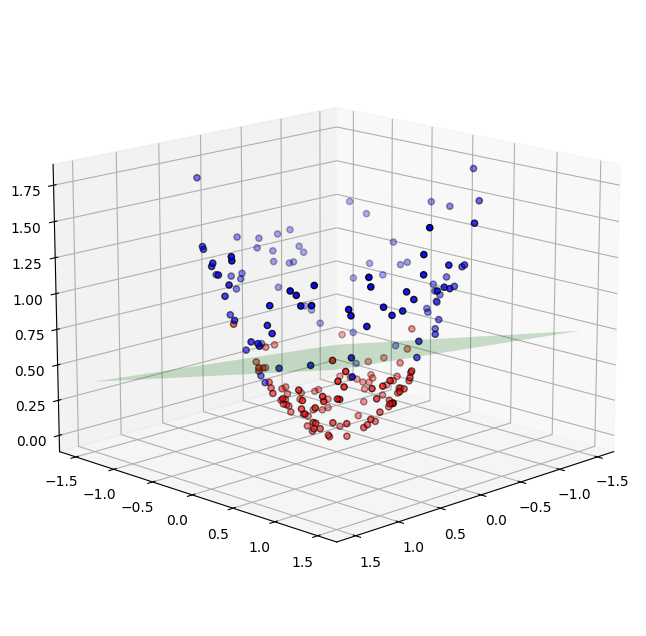

: 

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plota os pontos
ax.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=y, cmap='bwr', edgecolor='k')

# Calcula o plano de decisão para o gráfico
w = clf.coef_[0]
b = clf.intercept_[0]
x_plano, y_plano = np.meshgrid(np.linspace(-1.5, 1.5, 10), np.linspace(-1.5, 1.5, 10))
z_plano = -(w[0] * x_plano + w[1] * y_plano + b) / w[2]

# Plota o plano
ax.plot_surface(x_plano, y_plano, z_plano, alpha=0.2, color='green')
ax.view_init(elev=15, azim=45)
plt.show()